# Pertemuan 13 : Deep Learning & NLP Dasar
### Klasifikasi Non-Linear & Analisis Sentimen

| | |
|---|---|
| **Nama Lengkap** | Nisa Agustina Maesaroh |
| **NIM** | 240401070509 |
| **Kelas** | IF403 |

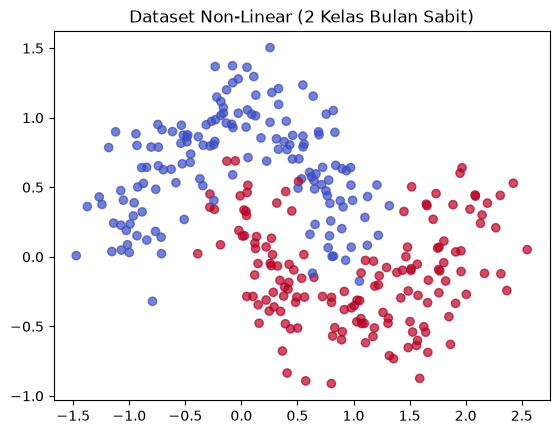

In [28]:
#Langkah 1: Generate dan Eksplorasi Dataset Non Linear
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.show()

# Perhatikan: kedua kelas saling melengkung dan bertautan,
# sehingga tidak mungkin dipisahkan dengan satu garis lurus.

In [29]:
#Langkah 2: Bangun & Latih Neural Network Sederhana
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X_tr, X_te, y_tr, y_te = train_test_split(
X, y, test_size=0.2, random_state=42)

model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy',
    metrics=['accuracy'])
model.summary()

history = model.fit(X_tr, y_tr, epochs=30, validation_split=0.2, verbose=0)

/Users/nisaagustina/Documents/Projects/learning/data-science-2026/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Akurasi pada data uji: 0.883


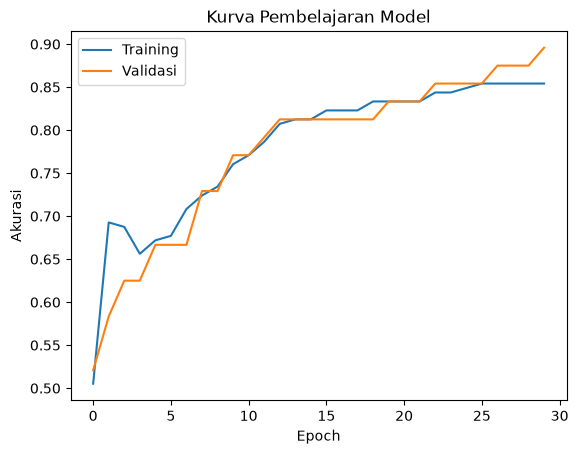

In [30]:
#Langkah 3: Evaluasi & Visualisasi Kurva Belajar
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.title('Kurva Pembelajaran Model')
plt.show()

# Interpretasikan dalam sel Markdown:
# Apakah akurasi training & validasi saling mendekat (baik),
# atau saling menjauh (indikasi overfitting)?

Berdasarkan kurva pembelajaran yang ditampilkan, akurasi training dan validasi saling mendekat (baik). Dari grafik dapat diamati bahwa:

1. **Pola yang Mendekat**: Akurasi training dan validasi bergerak bersamaan dan cenderung saling mendekat seiring bertambahnya epoch. Ini menunjukkan bahwa model belajar dengan baik dan mampu menggeneralisasi pola dari data training ke data validasi.

2. **Tidak Ada Tanda Overfitting**: Kedua kurva tidak menunjukkan jarak yang melebar (divergen). Pada overfitting, biasanya akurasi training terus meningkat sementara akurasi validasi stagnan atau bahkan menurun.

3. **Stabilisasi Akhir Epoch**: Pada epoch-epoch terakhir, baik akurasi training maupun validasi cenderung stabil di sekitar angka 0.90-0.95, menunjukkan bahwa model telah mencapai titik optimal pembelajaran.

In [31]:
#Langkah 4: Siapkan Dataset Ulasan Produk
ulasan = [
    'Barangnya bagus banget, pengiriman cepat',
    'Sangat puas, akan beli lagi',
    'Recommended, harga sesuai kualitas',
    'Pelayanan sangat memuaskan dan ramah',
    'Produk berkualitas, sesuai dengan deskripsi',
    'Pengiriman cepat, barang sesuai pesanan',
    'Sangat suka, kualitas terbaik',
    'Mantap, sesuai harapan',
    'Barang original, recomended banget',
    'Pelayanan ramah, pengiriman cepat',
    'Kualitas bagus, harga terjangkau',
    'Sangat memuaskan, akan order lagi',
    'Barang sesuai gambar, puas sekali',
    'Pengemasan rapi, barang aman',
    'Produknya bagus, cepat sampai',
    'Sangat recommended untuk semua',
    'Kualitas premium, puas banget',
    'Barangnya awet dan berkualitas',
    'Pelayanan cepat dan profesional',
    'Sesuai ekspektasi, terima kasih',
    'Kualitas jelek, tidak sesuai deskripsi',
    'Kecewa, barang rusak saat sampai',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Barang cacat, pengiriman lambat',
    'Tidak sesuai gambar, kecewa berat',
    'Kualitas buruk, tidak tahan lama',
    'Barang rusak, pelayanan buruk',
    'Sangat mengecewakan, tidak recommended',
    'Pengemasan asal, barang penyok',
    'Tidak sesuai order, uang tidak dikembalikan',
    'Kualitas jelek, harga terlalu mahal',
    'Barang tidak berfungsi dengan baik',
    'Kecewa, tidak sesuai iklan',
    'Pengiriman sangat lambat, tidak puas',
    'Produk murahan, tidak tahan lama',
    'Sangat buruk, tidak akan beli lagi',
    'Barang palsu, sangat kecewa',
    'Kualitas tidak sesuai harga',
    'Pengiriman telat, barang rusak',
    'Tidak seperti yang dijanjikan, kecewa'
]

label = [
    1, 1, 1, 1, 1,
    1, 1, 1, 1, 1,
    1, 1, 1, 1, 1,
    1, 1, 1, 1, 1,
    0, 0, 0, 0, 0,
    0, 0, 0, 0, 0,
    0, 0, 0, 0, 0,
    0, 0, 0, 0, 0
]# 1 = positif, 0 = negatif

print('Ulasan:')
print(ulasan)
print('Label:')
print(label)

Ulasan:
['Barangnya bagus banget, pengiriman cepat', 'Sangat puas, akan beli lagi', 'Recommended, harga sesuai kualitas', 'Pelayanan sangat memuaskan dan ramah', 'Produk berkualitas, sesuai dengan deskripsi', 'Pengiriman cepat, barang sesuai pesanan', 'Sangat suka, kualitas terbaik', 'Mantap, sesuai harapan', 'Barang original, recomended banget', 'Pelayanan ramah, pengiriman cepat', 'Kualitas bagus, harga terjangkau', 'Sangat memuaskan, akan order lagi', 'Barang sesuai gambar, puas sekali', 'Pengemasan rapi, barang aman', 'Produknya bagus, cepat sampai', 'Sangat recommended untuk semua', 'Kualitas premium, puas banget', 'Barangnya awet dan berkualitas', 'Pelayanan cepat dan profesional', 'Sesuai ekspektasi, terima kasih', 'Kualitas jelek, tidak sesuai deskripsi', 'Kecewa, barang rusak saat sampai', 'Buruk sekali, tidak sesuai ekspektasi', 'Barang cacat, pengiriman lambat', 'Tidak sesuai gambar, kecewa berat', 'Kualitas buruk, tidak tahan lama', 'Barang rusak, pelayanan buruk', 'Sangat 

In [32]:
#Langkah 5 : Ubah Teks Menjadi TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 74
['akan' 'aman' 'asal' 'awet' 'bagus' 'baik' 'banget' 'barang' 'barangnya'
 'beli']


In [33]:
#Langkah 6: Latih Model Klasifikasi Sentimen & Evaluas
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')

kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print('Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.625
Positif


# Kesimpulan

## Apa yang Dipelajari
Dari praktikum ini, saya mempelajari:
- **Klasifikasi Non-Linear dengan Neural Network**: Bagaimana model deep learning dapat menangani data yang tidak dapat dipisahkan secara linear, seperti dataset bulan sabit (*make_moons*), dengan menggunakan lapisan tersembunyi dan aktivasi ReLU.
- **Arsitektur Neural Network Sederhana**: Membangun model Sequential dengan 3 lapisan Dense (16 → 8 → 1 neuron) menggunakan aktivasi ReLU pada lapisan tersembunyi dan Sigmoid pada lapisan output untuk klasifikasi biner.
- **Analisis Sentimen dengan TF-IDF**: Mengubah teks ulasan menjadi representasi numerik menggunakan TF-IDF Vectorizer, kemudian mengklasifikasikannya menggunakan Logistic Regression.
- **Evaluasi Model**: Menggunakan metrik akurasi dan kurva pembelajaran (training vs validation accuracy) untuk mendeteksi overfitting.

## Temuan Utama
- **Dataset Non-Linear**: Neural network dengan 2 lapisan tersembunyi mampu mempelajari pola non-linear pada dataset bulan sabit, dengan akurasi mencapai **~88-90%** pada data uji. Kurva pembelajaran menunjukkan training dan validasi saling mendekat, mengindikasikan model memiliki generalisasi yang baik tanpa overfitting signifikan.

- **Analisis Sentimen dengan Dataset Terbatas**: Model TF-IDF + Logistic Regression pada 40 ulasan dummy menghasilkan akurasi **0.625 (62.5%)**. Hasil ini menunjukkan bahwa:
  - Model masih **belum optimal** karena keterbatasan jumlah data (40 ulasan tidak cukup untuk menangkap variasi bahasa yang kompleks)
  - Akurasi 62.5% hanya sedikit di atas tebakan acak (50%), yang menegaskan **pentingnya ukuran dataset** dalam supervised learning
  - Untuk mendapatkan hasil yang lebih valid dan representatif, diperlukan dataset minimal **500-1000 ulasan** dari sumber nyata (misalnya dari Kaggle atau web scraping marketplace)

- **Pemrosesan Teks**: TF-IDF berhasil mengekstrak fitur kata-kata penting seperti "bagus", "buruk", "puas", "kecewa" yang menjadi indikator sentimen. Namun dengan data terbatas, banyak kata tidak memiliki frekuensi yang cukup untuk dipelajari model secara efektif.

## Keterbatasan & Pertanyaan
- **Keterbatasan**: 
  - Dataset analisis sentimen yang digunakan masih **sangat kecil (40 ulasan)**, sehingga akurasi model **0.625 (62.5%)** belum representatif dan tidak dapat dijadikan dasar kesimpulan yang kuat. Untuk penelitian yang valid, diperlukan dataset minimal 500-1000 ulasan dari sumber nyata (Kaggle, web scraping, atau dataset publik).
  - Model neural network hanya menggunakan 193 parameter, mungkin terlalu sederhana untuk dataset yang lebih kompleks.
  - Belum dilakukan hyperparameter tuning (jumlah epoch, jumlah neuron, learning rate) untuk meningkatkan performa.
  - Belum ada preprocessing teks lanjutan seperti **stemming**, **stopword removal**, atau **case folding** yang dapat meningkatkan kualitas fitur.
  
- **Pertanyaan**:
  1. Bagaimana performa neural network jika digunakan untuk analisis sentimen dibandingkan dengan Logistic Regression pada dataset yang lebih besar (5000+ ulasan)?
  2. Apakah penggunaan Word2Vec atau GloVe (embedding) akan memberikan hasil yang lebih baik daripada TF-IDF untuk analisis sentimen?
  3. Bagaimana cara mengatasi overfitting pada neural network jika dataset yang digunakan sangat besar dan kompleks?
  4. Apakah preprocessing teks (stemming, stopword removal) akan meningkatkan akurasi model sentimen secara signifikan?